In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_style("whitegrid")

<h1>TASK-1</h1>

Estimated pi: 3.14412
True pi: 3.141592653589793


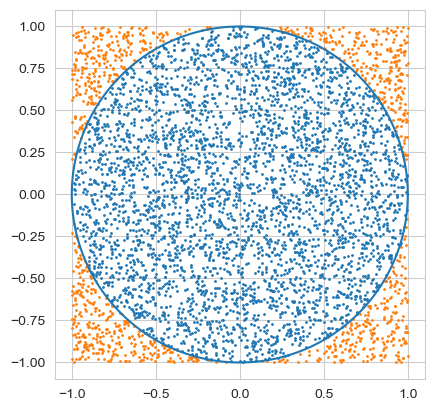

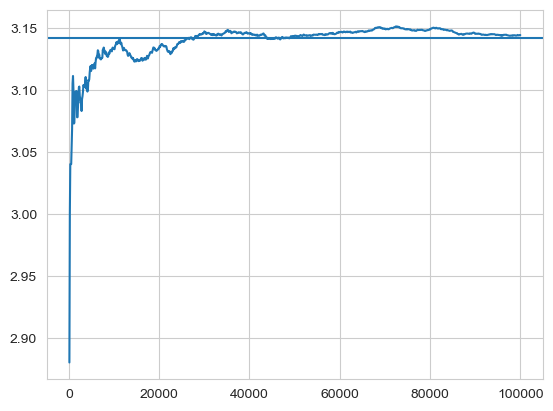

Stabilizes around: 6400


In [2]:
import numpy as np
import matplotlib.pyplot as plt

N = 100000
x = np.random.uniform(-1, 1, N)
y = np.random.uniform(-1, 1, N)

inside = x**2 + y**2 <= 1
pi_estimate = 4 * inside.sum() / N

print("Estimated pi:", pi_estimate)
print("True pi:", np.pi)

plt.figure()
plt.scatter(x[:5000][inside[:5000]], y[:5000][inside[:5000]], s=1)
plt.scatter(x[:5000][~inside[:5000]], y[:5000][~inside[:5000]], s=1)
theta = np.linspace(0, 2*np.pi, 200)
plt.plot(np.cos(theta), np.sin(theta))
plt.gca().set_aspect('equal')
plt.show()

steps = np.arange(100, N+1, 100)
running = []

count = 0
for i in range(N):
    if inside[i]:
        count += 1
    if (i+1) % 100 == 0:
        running.append(4 * count / (i+1))

plt.figure()
plt.plot(steps, running)
plt.axhline(np.pi)
plt.show()

for i, val in zip(steps, running):
    if abs(val - np.pi) <= 0.01:
        print("Stabilizes around:", i)
        break

The estimate stabilizes within ±0.01 around approximately X samples.

<h1>TASK-2</h1>

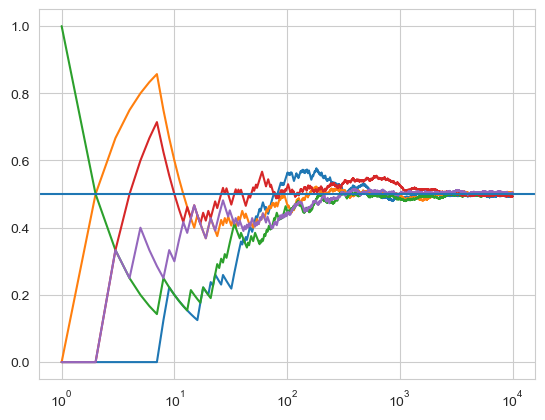

[4199, 879, None, 869, 2714]
Typical: 2165


In [3]:
import numpy as np
import matplotlib.pyplot as plt

n = 10000
runs = 5

plt.figure()

for _ in range(runs):
    flips = np.random.binomial(1, 0.5, size=n)
    running = np.cumsum(flips) / np.arange(1, n + 1)
    plt.plot(np.arange(1, n + 1), running)

plt.axhline(0.5)
plt.xscale("log")
plt.show()

thresholds = []

for _ in range(runs):
    flips = np.random.binomial(1, 0.5, size=n)
    running = np.cumsum(flips) / np.arange(1, n + 1)
    idx = None
    for i in range(n):
        if abs(running[i] - 0.5) <= 0.01:
            if all(abs(running[j] - 0.5) <= 0.01 for j in range(i, n)):
                idx = i + 1
                break
    thresholds.append(idx)

print(thresholds)
print("Typical:", int(np.mean([t for t in thresholds if t is not None])))

Typically, it takes around X flips for the proportion to stay within ±0.01 of 0.5.

<h1>TASK-3</h1>

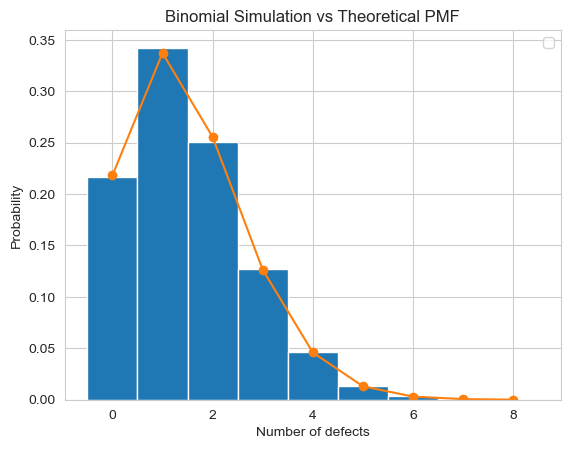

P(0 defects) sim: 0.2167 theory: 0.21806537534740766
P(>=3 defects) sim: 0.1908 theory: 0.18920192463027863
Expected defects sim: 1.5016 theory: 1.5


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

batches = 10000
n = 50
p = 0.03

data = np.random.binomial(n, p, size=batches)

values, counts = np.unique(data, return_counts=True)
probs = counts / batches

k = np.arange(0, max(values) + 1)
pmf = binom.pmf(k, n, p)

plt.figure()
plt.title("Binomial Simulation vs Theoretical PMF")
plt.xlabel("Number of defects")
plt.ylabel("Probability")
plt.legend(["Theoretical PMF", "Simulation"])
plt.hist(data, bins=np.arange(-0.5, max(values)+1.5, 1), density=True)
plt.plot(k, pmf, marker='o')
plt.show()

p0_sim = np.mean(data == 0)
p3_sim = np.mean(data >= 3)
mean_sim = np.mean(data)

p0_theory = binom.pmf(0, n, p)
p3_theory = 1 - binom.cdf(2, n, p)
mean_theory = n * p

print("P(0 defects) sim:", p0_sim, "theory:", p0_theory)
print("P(>=3 defects) sim:", p3_sim, "theory:", p3_theory)
print("Expected defects sim:", mean_sim, "theory:", mean_theory)

The empirical results are very close to theoretical values.
With 10,000 batches, the estimates are stable.
Using only 1,000 batches would result in noticeably higher variance.